In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('pastel')
pd.set_option('display.max_columns', None)

In [3]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('social_media_engagement_5000.csv')
print("Dataset successfully loaded!")

Saving social_media_engagement_5000.csv to social_media_engagement_5000.csv
Dataset successfully loaded!


In [4]:
print("=== FIRST 5 ROWS ===")
display(df.head())

print("\n=== DATA TYPES ===")
print(df.dtypes)

date_cols = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower() and 'watch' not in col.lower()]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print("\nUpdated Datatypes:")
print(df.dtypes)

=== FIRST 5 ROWS ===


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372



=== DATA TYPES ===
user_id               int64
age                 float64
gender               object
country              object
post_id               int64
post_type            object
post_category        object
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at            object
follower_count        int64
is_verified            bool
device_type          object
sentiment            object
hashtags             object
engagement_rate     float64
dtype: object

Updated Datatypes:
user_id                      int64
age                        float64
gender                      object
country                     object
post_id                      int64
post_type                   object
post_category               object
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count             

/tmp/ipykernel_3615/2045479050.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')


In [5]:
print("Missing values per column prior to cleaning:")
print(df.isnull().sum())


num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


duplicates = df.duplicated().sum()
print(f"\nDuplicates found: {duplicates}")
df = df.drop_duplicates()


if 'gender' in df.columns:
    df['gender'] = df['gender'].astype(str).str.strip().str.capitalize()
    df['gender'] = df['gender'].replace({'M': 'Male', 'F': 'Female', 'Femal': 'Female'})


for col in ['likes', 'comments', 'shares']:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: max(0, x))


if 'hashtags' in df.columns:
    df['hashtag_count'] = df['hashtags'].astype(str).apply(lambda x: len(x.split()) if x != 'nan' else 0)

if 'sentiment' in df.columns:
    df['sentiment'] = df['sentiment'].astype(str).str.strip().str.lower()

print("\nCleaning completed successfully.")

Missing values per column prior to cleaning:
user_id                0
age                  150
gender               150
country                0
post_id                0
post_type              0
post_category          0
likes                150
comments             150
shares               150
watch_time_sec         0
impression_count       0
posted_at              0
follower_count         0
is_verified            0
device_type            0
sentiment           5000
hashtags               0
engagement_rate        0
dtype: int64

Duplicates found: 0

Cleaning completed successfully.


In [6]:
print(f"Dataset Shape: {df.shape}")
print("\n=== DATASET INFO ===")
df.info()

print("\n=== SUMMARY STATISTICS ===")
display(df.describe())


for col in ['post_type', 'country', 'sentiment', 'device']:
    if col in df.columns:
        print(f"\nDistribution for {col}:")
        print(df[col].value_counts())


numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
print("\n=== CORRELATION MATRIX ===")
display(corr_matrix)


if 'post_type' in df.columns and 'likes' in df.columns:
    print("\nAverage Likes by Post Type:")
    print(df.groupby('post_type')['likes'].mean())

if 'country' in df.columns and 'impressions' in df.columns:
    print("\nTotal Impressions by Country:")
    print(df.groupby('country')['impressions'].sum())

Dataset Shape: (5000, 20)

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               5000 non-null   float64
 2   gender            5000 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             5000 non-null   float64
 8   comments          5000 non-null   float64
 9   shares            5000 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10106.997400,1502.039800,1002.9106,4014.503200,50013.732800,393698.224800,0.964356,1.998600
std,26090.370121,14.687151,260646.957267,5702.293017,856.393312,570.8552,2308.096459,28844.939104,230927.884535,5.318029,0.812853
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,194480.000000,0.145781,1.000000
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.0000,4034.500000,49934.500000,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,799533.000000,191.504348,3.000000



Distribution for post_type:
post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64

Distribution for country:
country
India        535
Canada       513
Brazil       504
UAE          503
USA          501
France       496
UK           493
Australia    493
Germany      490
Japan        472
Name: count, dtype: int64

Distribution for sentiment:
sentiment
nat    5000
Name: count, dtype: int64

=== CORRELATION MATRIX ===


,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
user_id,1.000000,-0.006688,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,-0.004282,-0.013692
age,-0.006688,1.000000,-0.013153,-0.036322,-0.007284,0.013871,0.005542,0.013322,-0.024894,0.008039,0.007173
post_id,0.020051,-0.013153,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.010139,0.007344
likes,0.025811,-0.036322,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,0.093520,-0.002190
comments,-0.033395,-0.007284,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,0.000051,-0.015230
shares,0.013763,0.013871,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.021724,0.013379
watch_time_sec,-0.016847,0.005542,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,-0.001148,-0.023301
impression_count,0.015326,0.013322,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,-0.232226,-0.002714
follower_count,0.010124,-0.024894,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,0.002292,0.008802
engagement_rate,-0.004282,0.008039,0.010139,0.093520,0.000051,0.021724,-0.001148,-0.232226,0.002292,1.000000,0.005319



Average Likes by Post Type:
post_type
image    10104.865277
reel     10037.802416
text     10100.148193
video    10188.600000
Name: likes, dtype: float64


In [7]:
if 'engagement_rate' not in df.columns and all(c in df.columns for c in ['likes', 'comments', 'shares', 'impressions']):
    df['engagement_score'] = (df['likes'] + df['comments'] + df['shares']) / (df['impressions'] + 1)
else:
    df['engagement_score'] = df.get('engagement_rate', df['likes'] + df['comments'] + df['shares'])


for col in ['likes', 'impressions', 'followers']:
    if col in df.columns:
        df[f'log_{col}'] = np.log1p(df[col])


wrangled_summary = df.groupby(['post_type', 'sentiment']).agg({
    'likes': 'mean',
    'comments': 'mean',
    'shares': 'mean',
    'engagement_score': 'mean'
}).reset_index()

display(wrangled_summary.head(10))

,post_type,sentiment,likes,comments,shares,engagement_score
0,image,nat,10104.865277,1525.235766,1019.289495,0.895646
1,reel,nat,10037.802416,1504.187062,982.042089,0.783047
2,text,nat,10100.148193,1499.106024,1013.989558,1.064549
3,video,nat,10188.600000,1479.160000,996.834286,1.122365


In [8]:
target_cols = ['likes', 'comments', 'shares', 'watch_time', 'engagement_rate', 'followers', 'engagement_score']
valid_cols = [c for c in target_cols if c in df.columns]

stats_dict = {}
for col in valid_cols:
    stats_dict[col] = {
        'Mean': df[col].mean(),
        'Median': df[col].median(),
        'Mode': df[col].mode()[0],
        'Std Dev': df[col].std(),
        'Variance': df[col].var(),
        '25th Percentile': df[col].quantile(0.25),
        '75th Percentile': df[col].quantile(0.75),
        'Skewness': df[col].skew(),
        'Kurtosis': df[col].kurtosis()
    }

stats_df = pd.DataFrame(stats_dict).T
display(stats_df)

,Mean,Median,Mode,Std Dev,Variance,25th Percentile,75th Percentile,Skewness,Kurtosis
likes,10106.997400,10105.500000,10105.500000,5702.293017,3.251615e+07,5235.000000,14959.000000,-0.006894,-1.149992
comments,1502.039800,1497.000000,1497.000000,856.393312,7.334095e+05,792.000000,2235.250000,0.003802,-1.144375
shares,1002.910600,1012.000000,1012.000000,570.855200,3.258757e+05,511.000000,1483.000000,-0.014654,-1.146857
engagement_rate,0.964356,0.253896,0.006363,5.318029,2.828143e+01,0.145781,0.504794,18.781271,482.991739
engagement_score,0.964356,0.253896,0.006363,5.318029,2.828143e+01,0.145781,0.504794,18.781271,482.991739


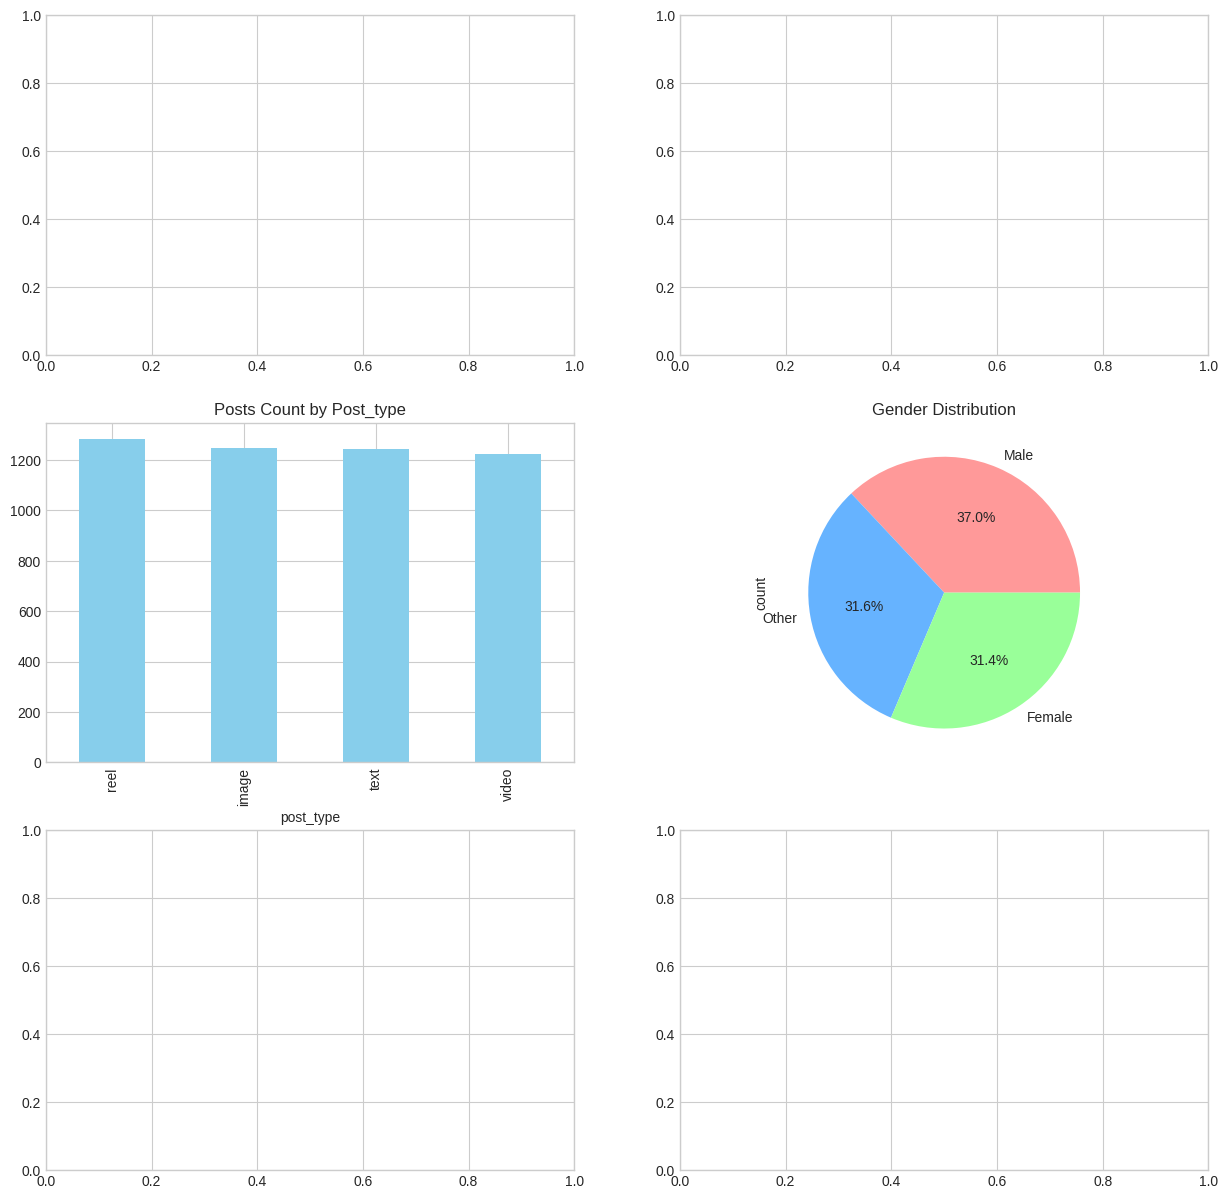

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))

# Scatter Plot: Likes vs Impressions
if 'impressions' in df.columns and 'likes' in df.columns:
    axes[0, 0].scatter(df['impressions'], df['likes'], alpha=0.5, color='teal')
    axes[0, 0].set_title('Likes vs. Impressions')
    axes[0, 0].set_xlabel('Impressions')
    axes[0, 0].set_ylabel('Likes')

# Line Plot: Daily Engagement Trend
date_col = [c for c in df.columns if 'date' in c.lower()]
if date_col and 'engagement_score' in df.columns:
    daily_trend = df.groupby(date_col[0])['engagement_score'].mean()
    axes[0, 1].plot(daily_trend.index, daily_trend.values, color='coral', linewidth=1.5)
    axes[0, 1].set_title('Daily Engagement Trend')
    axes[0, 1].set_xlabel('Date')
    axes[0, 1].set_ylabel('Avg Engagement Score')

# Bar Plot: Posts by Category
cat_col = 'category' if 'category' in df.columns else 'post_type'
if cat_col in df.columns:
    df[cat_col].value_counts().plot(kind='bar', ax=axes[1, 0], color='skyblue')
    axes[1, 0].set_title(f'Posts Count by {cat_col.capitalize()}')

# Pie Chart: Gender Distribution
if 'gender' in df.columns:
    df['gender'].value_counts().plot(kind='pie', ax=axes[1, 1], autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
    axes[1, 1].set_title('Gender Distribution')

/tmp/ipykernel_3615/314711650.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='post_type', palette='Set2')
/tmp/ipykernel_3615/314711650.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='post_type', y='likes', palette='viridis')


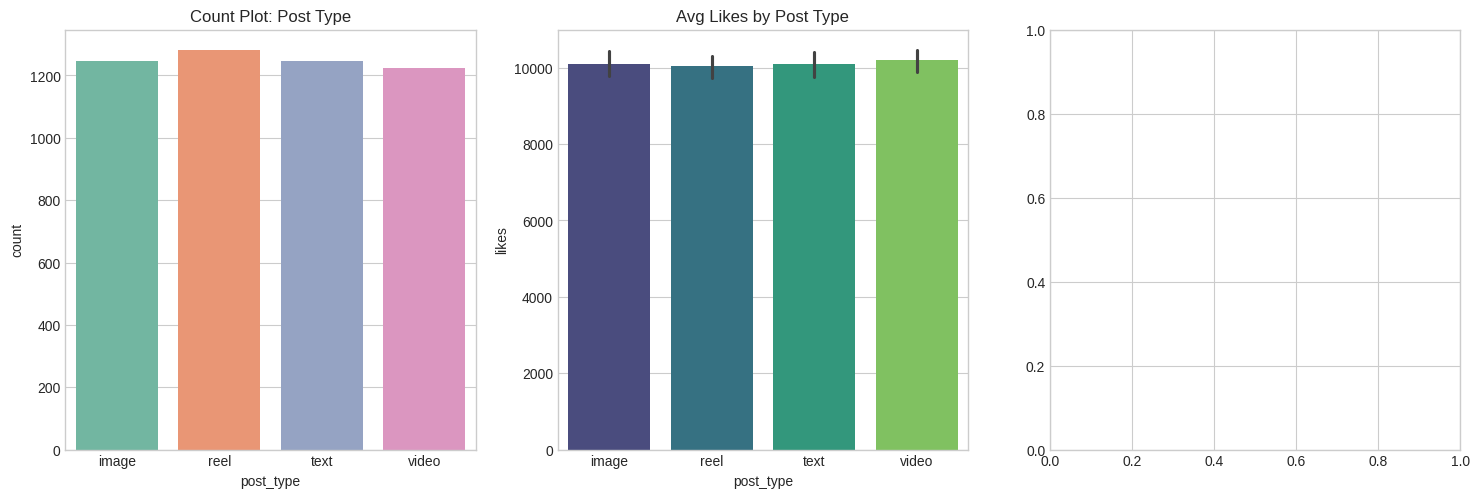

In [10]:
plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1)
if 'post_type' in df.columns:
    sns.countplot(data=df, x='post_type', palette='Set2')
    plt.title('Count Plot: Post Type')

plt.subplot(2, 3, 2)
if 'post_type' in df.columns and 'likes' in df.columns:
    sns.barplot(data=df, x='post_type', y='likes', palette='viridis')
    plt.title('Avg Likes by Post Type')

plt.subplot(2, 3, 3)
if 'followers' in df.columns and 'sentiment' in df.columns:
    sns.violinplot(data=df, x='sentiment', y='log_followers' if 'log_followers' in df.columns else 'followers', palette='Pastel1')
    plt.title('Followers Distribution vs Sentiment')

In [15]:
print("="*60)
print("             FINAL INSIGHTS & ANALYTICAL REPORT")
print("="*60)

# 1. Content Performance
if 'post_type' in df.columns and 'likes' in df.columns:
    top_post = df.groupby('post_type')['likes'].mean().idxmax()
    print(f"\n1. CONTENT PERFORMANCE:")
    print(f"   • Post Type with Highest Avg Engagement/Likes: {top_post}")

if 'country' in df.columns and 'engagement_score' in df.columns:
    top_country = df.groupby('country')['engagement_score'].mean().idxmax()
    print(f"   • Country with Highest Avg Engagement Rate: {top_country}")

# 2. User Trends
if 'age' in df.columns and 'engagement_score' in df.columns:
    age_corr = df['age'].corr(df['engagement_score'])
    print(f"\n2. USER TRENDS:")
    print(f"   • Correlation between Age and Engagement: {age_corr:.4f}")

if 'is_verified' in df.columns and 'engagement_score' in df.columns:
    verified_eng = df.groupby('is_verified')['engagement_score'].mean()
    print(f"   • Engagement Performance (Verified vs Non-Verified):\n{verified_eng.to_string()}")

# 3. Behavioral Insights
if 'post_time' in df.columns and 'impressions' in df.columns:
    df['hour'] = pd.to_datetime(df['post_time'], errors='coerce').dt.hour
    best_hour = df.groupby('hour')['impressions'].mean().idxmax()
    print(f"\n3. BEHAVIORAL INSIGHTS:")
    print(f"   • Peak Hour for Highest Impressions: {best_hour}:00")

if 'device' in df.columns and 'watch_time' in df.columns:
    best_device = df.groupby('device')['watch_time'].mean().idxmax()
    print(f"   • Device Type with Highest Average Watch Time: {best_device}")

# 4. Sentiment Analysis
if 'sentiment' in df.columns and 'engagement_score' in df.columns:
    sentiment_perf = df.groupby('sentiment')['engagement_score'].mean()
    print(f"\n4. SENTIMENT ANALYSIS:")
    print(f"   • Sentiment-wise Engagement Rate Performance:\n{sentiment_perf.to_string()}")

             FINAL INSIGHTS & ANALYTICAL REPORT

1. CONTENT PERFORMANCE:
   • Post Type with Highest Avg Engagement/Likes: video
   • Country with Highest Avg Engagement Rate: Brazil

2. USER TRENDS:
   • Correlation between Age and Engagement: 0.0080
   • Engagement Performance (Verified vs Non-Verified):
is_verified
False    0.954744
True     1.054250

4. SENTIMENT ANALYSIS:
   • Sentiment-wise Engagement Rate Performance:
sentiment
nat    0.964356
